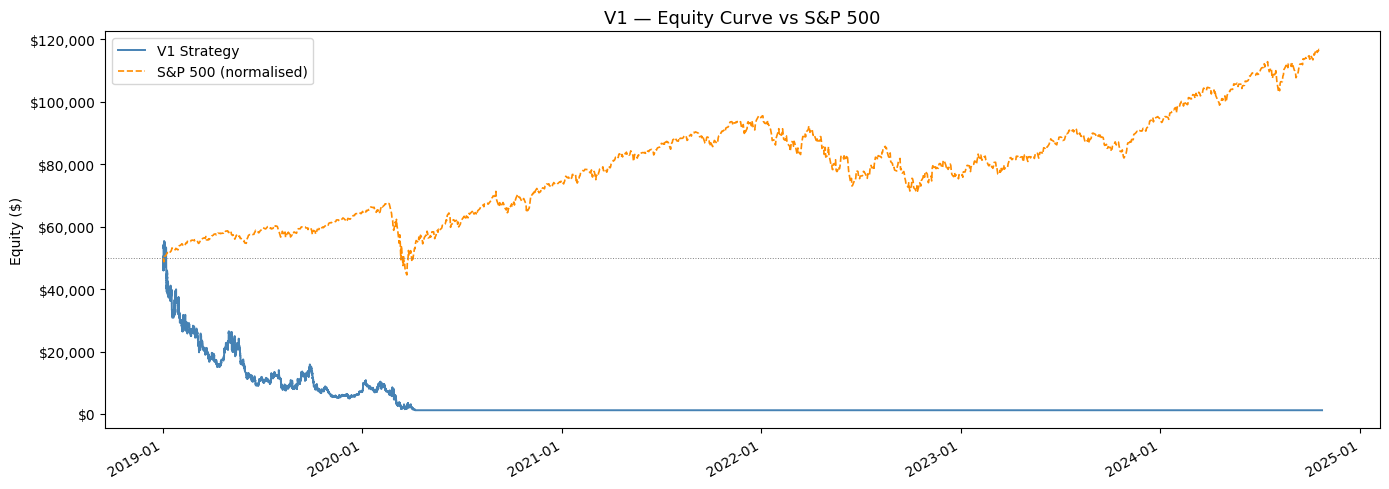

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ── Load iteration artifacts ──────────────────────────────────────────────────
ec   = pd.read_csv("equity_curve.csv", parse_dates=["time"])
meta = json.load(open("metadata.json"))
VERSION  = meta["version"]
START_EQ = meta["STARTING_EQUITY"]

# ── Fetch S&P 500 for same period ─────────────────────────────────────────────
import yfinance as yf
start_dt = ec["time"].dt.date.min().isoformat()
end_dt   = ec["time"].dt.date.max().isoformat()
sp_raw   = yf.download("^GSPC", start=start_dt, end=end_dt,
                        auto_adjust=True, progress=False)["Close"].squeeze()
sp_norm  = sp_raw / sp_raw.iloc[0] * START_EQ  # normalised to same start equity

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ec["time"], ec["equity"], color="steelblue", lw=1.4,
        label=f"{VERSION} Strategy")
ax.plot(sp_norm.index, sp_norm.values, color="darkorange", lw=1.2,
        linestyle="--", label="S&P 500 (normalised)")
ax.axhline(START_EQ, color="gray", lw=0.7, linestyle=":")
ax.set_title(f"{VERSION} — Equity Curve vs S&P 500", fontsize=13)
ax.set_ylabel("Equity ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


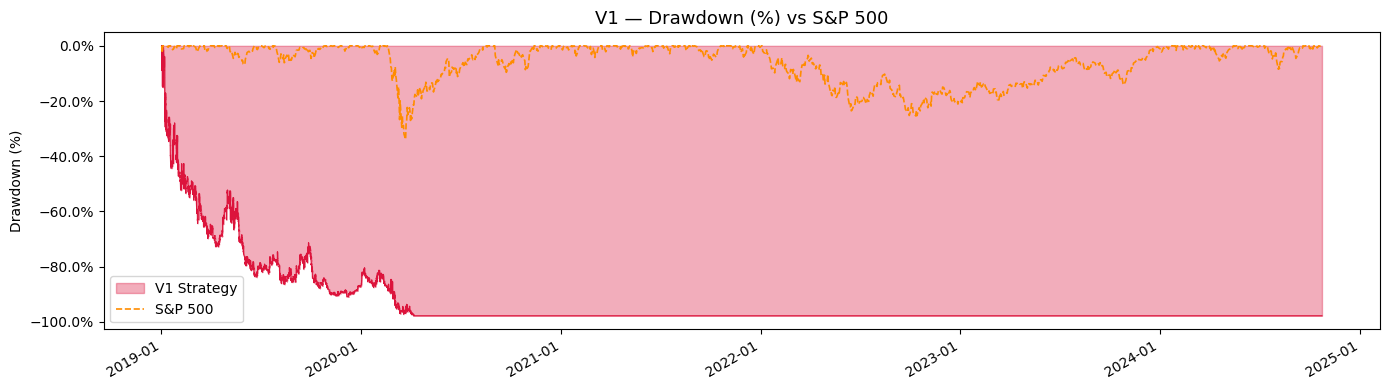

In [2]:
# ── Compute strategy drawdown ─────────────────────────────────────────────────
eq_vals = ec["equity"].values
eq_peak = np.maximum.accumulate(eq_vals)
dd_pct  = (eq_vals - eq_peak) / eq_peak * 100

# ── Compute S&P 500 drawdown ──────────────────────────────────────────────────
sp_vals = sp_norm.values
sp_peak = np.maximum.accumulate(sp_vals)
sp_dd   = (sp_vals - sp_peak) / sp_peak * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(ec["time"], dd_pct, 0, alpha=0.35, color="crimson",
                label=f"{VERSION} Strategy")
ax.plot(ec["time"], dd_pct, color="crimson", lw=0.8)
ax.plot(sp_norm.index, sp_dd, color="darkorange", lw=1.2,
        linestyle="--", label="S&P 500")
ax.set_title(f"{VERSION} — Drawdown (%) vs S&P 500", fontsize=13)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.1f}%"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [3]:

from IPython.display import display

trades = pd.read_csv("trades.csv", parse_dates=["entry_time", "exit_time"])

# ── Strategy metrics ──────────────────────────────────────────────────────────
daily_ec  = ec.set_index("time")["equity"].resample("D").last().dropna()
daily_ret = daily_ec.pct_change().dropna()
TRADING_DAYS = 252

n_days        = (ec["time"].iloc[-1] - ec["time"].iloc[0]).days
final_eq      = ec["equity"].iloc[-1]
total_ret_pct = (final_eq / START_EQ - 1) * 100
ann_ret_pct   = ((final_eq / START_EQ) ** (365 / max(n_days, 1)) - 1) * 100
sharpe        = (daily_ret.mean() / daily_ret.std() * TRADING_DAYS**0.5
                 if daily_ret.std() > 0 else 0.0)
max_dd_pct    = dd_pct.min()
win_rate      = trades["label_win"].mean() * 100
n_trades      = len(trades)
exit_counts   = trades["exit_reason"].value_counts().to_dict()

# ── S&P 500 metrics ───────────────────────────────────────────────────────────
sp_ret_daily = sp_raw.pct_change().dropna()
sp_n_days    = (sp_raw.index[-1] - sp_raw.index[0]).days
sp_total_ret = (sp_raw.iloc[-1] / sp_raw.iloc[0] - 1) * 100
sp_ann_ret   = ((sp_raw.iloc[-1] / sp_raw.iloc[0]) ** (365 / max(sp_n_days, 1)) - 1) * 100
sp_sharpe    = (sp_ret_daily.mean() / sp_ret_daily.std() * TRADING_DAYS**0.5
                if sp_ret_daily.std() > 0 else 0.0)
sp_max_dd    = sp_dd.min()

# ── Comparison table ──────────────────────────────────────────────────────────
rows = {
    "Total Return (%)":       [f"{total_ret_pct:+.2f}%", f"{sp_total_ret:+.2f}%"],
    "Annualised Return (%)":  [f"{ann_ret_pct:+.2f}%",   f"{sp_ann_ret:+.2f}%"],
    "Sharpe Ratio (ann.)":    [f"{sharpe:.3f}",           f"{sp_sharpe:.3f}"],
    "Max Drawdown (%)":       [f"{max_dd_pct:.2f}%",      f"{sp_max_dd:.2f}%"],
    "Win Rate (%)":           [f"{win_rate:.1f}%",         "N/A"],
    "Trades Taken":           [f"{n_trades:,}",            "N/A"],
    "Exit: Take Profit":      [f"{exit_counts.get('take_profit', 0):,}", "N/A"],
    "Exit: Stop Loss":        [f"{exit_counts.get('stop', 0):,}",        "N/A"],
    "Exit: Opposite Signal":  [f"{exit_counts.get('opposite_signal', 0):,}", "N/A"],
    "Exit: End of Data":      [f"{exit_counts.get('end_of_data', 0):,}", "N/A"],
}
metrics_df = pd.DataFrame(rows, index=[VERSION, "S&P 500"]).T
display(
    metrics_df.style
    .set_caption(f"{VERSION} — Key Performance Metrics vs S&P 500")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"),
                                  ("font-weight", "bold"),
                                  ("text-align", "left")]}])
)


,V1,S&P 500
Total Return (%),-97.61%,+133.11%
Annualised Return (%),-47.40%,+15.69%
Sharpe Ratio (ann.),-0.538,0.821
Max Drawdown (%),-97.85%,-33.92%
Win Rate (%),5.9%,N/A
Trades Taken,"52,187",N/A
Exit: Take Profit,"2,800",N/A
Exit: Stop Loss,"2,173",N/A
Exit: Opposite Signal,"47,213",N/A
Exit: End of Data,1,N/A


In [4]:

mc = json.load(open("monte_carlo.json"))
dd = mc["max_drawdown"]

mc_rows = {
    "Bootstrap Method":         [mc["bootstrap_method"]],
    "Simulations":              [f"{mc['n_sims']:,}"],
    "Observed Trades":          [f"{mc['n_trades']:,}"],
    "Seed":                     [mc["seed"]],
    "Max Drawdown p50 ($)":     [f"${dd['p50']:,.2f}"],
    "Max Drawdown p90 ($)":     [f"${dd['p90']:,.2f}"],
    "Max Drawdown p95 ($)":     [f"${dd['p95']:,.2f}"],
    "Max Drawdown p99 ($)":     [f"${dd['p99']:,.2f}"],
    "Max Drawdown Worst ($)":   [f"${dd['worst']:,.2f}"],
    "VaR 5th pct (per trade)":  [f"${mc['var_trade_pnl']:,.2f}"],
    "CVaR 5th pct (per trade)": [f"${mc['cvar_trade_pnl']:,.4f}"],
    "Risk of Ruin Prob":        [f"{mc['risk_of_ruin_prob']*100:.1f}%"],
    "Ruin Definition":          [mc["ruin_definition"]],
}
mc_df = pd.DataFrame(mc_rows, index=["Value"]).T
display(
    mc_df.style
    .set_caption(
        f"{VERSION} — Monte Carlo Risk Metrics "
        f"(IID Bootstrap, {mc['n_sims']:,} sims)"
    )
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"),
                                  ("font-weight", "bold"),
                                  ("text-align", "left")]}])
)


,Value
Bootstrap Method,iid
Simulations,"10,000"
Observed Trades,"52,187"
Seed,42
Max Drawdown p50 ($),"$61,653.25"
Max Drawdown p90 ($),"$92,730.90"
Max Drawdown p95 ($),"$101,219.60"
Max Drawdown p99 ($),"$118,563.48"
Max Drawdown Worst ($),"$151,132.00"
VaR 5th pct (per trade),$-76.50


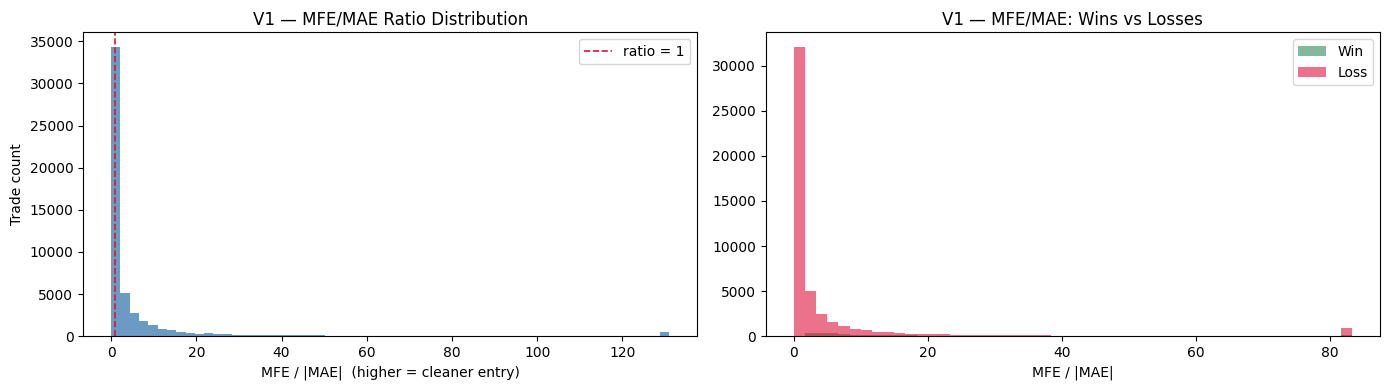

,Count,Mean,Median,P75,Max
All trades,52187,7.754472,0.870968,4.200000,749.000000
Wins,3090,21.997612,9.857143,24.000000,432.000000
Losses,49097,6.858056,0.756757,3.187500,749.000000


In [5]:

# ── Track A Cell 4: MFE/MAE Ratio ─────────────────────────────────────────────
# If entry_score / mfe_mae_ratio are already in trades (post-Cython rerun),
# use them directly; otherwise compute from existing columns.

if "mfe_mae_ratio" not in trades.columns:
    mae_abs = trades["mae_points"].abs().clip(lower=0.25)
    trades["mfe_mae_ratio"] = trades["mfe_points"] / mae_abs

ratio = trades["mfe_mae_ratio"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(ratio.clip(upper=ratio.quantile(0.99)), bins=60,
             color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(1.0, color="crimson", lw=1.2, linestyle="--", label="ratio = 1")
axes[0].set_title(f"{VERSION} — MFE/MAE Ratio Distribution")
axes[0].set_xlabel("MFE / |MAE|  (higher = cleaner entry)")
axes[0].set_ylabel("Trade count")
axes[0].legend()

# Win vs loss comparison
wins_ratio   = trades.loc[trades["label_win"] == 1, "mfe_mae_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
losses_ratio = trades.loc[trades["label_win"] == 0, "mfe_mae_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
cap = ratio.quantile(0.98)
axes[1].hist(wins_ratio.clip(upper=cap),   bins=50, alpha=0.6, color="seagreen", label="Win")
axes[1].hist(losses_ratio.clip(upper=cap), bins=50, alpha=0.6, color="crimson",  label="Loss")
axes[1].set_title(f"{VERSION} — MFE/MAE: Wins vs Losses")
axes[1].set_xlabel("MFE / |MAE|")
axes[1].legend()

plt.tight_layout()
plt.show()

stats = pd.DataFrame({
    "All trades":   ratio.describe(),
    "Wins":         wins_ratio.describe(),
    "Losses":       losses_ratio.describe(),
}).T[["count", "mean", "50%", "75%", "max"]]
stats.columns = ["Count", "Mean", "Median", "P75", "Max"]
display(stats.style.set_caption(f"{VERSION} — MFE/MAE Ratio Stats")
        .format("{:.3f}").format({"Count": "{:.0f}"}))


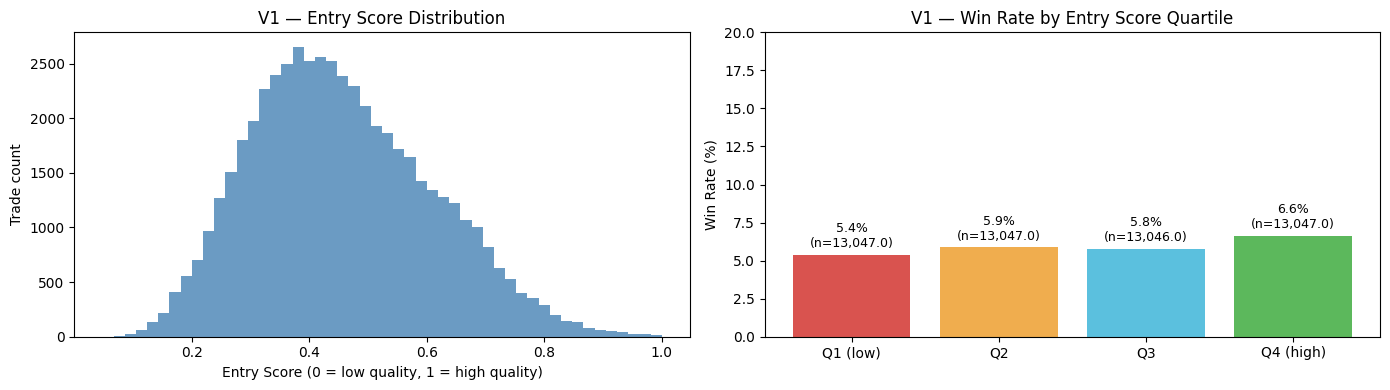

In [6]:

# ── Track A Cell 5: Entry Score Distribution & Win Rate by Quartile ───────────
# Scoring weights (must match src/config.py SCORE_W_* values)
W_Z, W_VOL, W_EMA, W_BODY, W_SES = 0.25, 0.20, 0.20, 0.20, 0.15
EMA_NORM = 5.0
Z_BAND_K = meta.get("Z_BAND_K", 2.5)

def session_score(hhmm_str):
    try:
        h = int(hhmm_str)
    except (ValueError, TypeError):
        return np.nan
    if 830 <= h < 1515:
        return 1.0
    if (600 <= h < 830) or (1515 <= h < 1700):
        return 0.6
    return 0.3

if "entry_score" not in trades.columns:
    # Compute from stored feature columns
    def _score_row(r):
        num, den = 0.0, 0.0
        def _add(w, v):
            nonlocal num, den
            if not np.isnan(v):
                num += w * np.clip(v, 0, 1); den += w
        ze = r.get("zscore_entry", np.nan)
        if not np.isnan(float(ze if ze is not None else np.nan)):
            _add(W_Z, abs(float(ze)) / Z_BAND_K)
        vz = r.get("volume_zscore", np.nan)
        if not np.isnan(float(vz if vz is not None else np.nan)):
            _add(W_VOL, (float(vz) + 2) / 4)
        es = r.get("ema_spread", np.nan)
        if not np.isnan(float(es if es is not None else np.nan)):
            _add(W_EMA, abs(float(es)) / EMA_NORM)
        rng = r.get("bar_range_points", 0)
        bod = r.get("bar_body_points", np.nan)
        if float(rng) >= 0.25 and not np.isnan(float(bod)):
            _add(W_BODY, float(bod) / float(rng))
        _add(W_SES, session_score(r.get("time_of_day_hhmm", "")))
        return num / den if den > 0 else np.nan
    trades["entry_score"] = trades.apply(_score_row, axis=1)

score = trades["entry_score"].dropna()
trades["score_quartile"] = pd.qcut(trades["entry_score"], q=4,
                                    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
wr_by_q = trades.groupby("score_quartile", observed=True)["label_win"].agg(
    win_rate=lambda x: x.mean() * 100,
    n_trades="count",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(score, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_title(f"{VERSION} — Entry Score Distribution")
axes[0].set_xlabel("Entry Score (0 = low quality, 1 = high quality)")
axes[0].set_ylabel("Trade count")

colors = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c"]
bars = axes[1].bar(wr_by_q.index, wr_by_q["win_rate"], color=colors, edgecolor="none")
for bar, (_, row) in zip(bars, wr_by_q.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['win_rate']:.1f}%\n(n={row['n_trades']:,})",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title(f"{VERSION} — Win Rate by Entry Score Quartile")
axes[1].set_ylabel("Win Rate (%)")
axes[1].set_ylim(0, max(wr_by_q["win_rate"].max() * 1.25, 20))

plt.tight_layout()
plt.show()


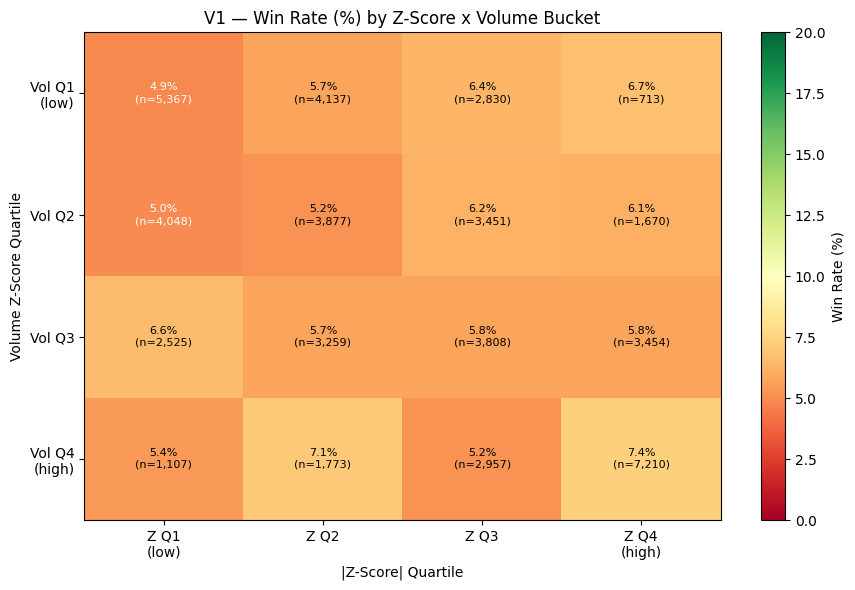

In [7]:

# ── Track A Cell 6: Win-Rate Bucket Heatmap (Z-score x Volume) ────────────────
hm_trades = trades.dropna(subset=["zscore_entry", "volume_zscore"]).copy()

hm_trades["z_q"]   = pd.qcut(hm_trades["zscore_entry"].abs(), q=4,
                               labels=["Z Q1\n(low)", "Z Q2", "Z Q3", "Z Q4\n(high)"])
hm_trades["vol_q"] = pd.qcut(hm_trades["volume_zscore"], q=4,
                               labels=["Vol Q1\n(low)", "Vol Q2", "Vol Q3", "Vol Q4\n(high)"])

pivot_wr = hm_trades.pivot_table(
    values="label_win", index="vol_q", columns="z_q",
    aggfunc="mean", observed=True
) * 100

pivot_n = hm_trades.pivot_table(
    values="label_win", index="vol_q", columns="z_q",
    aggfunc="count", observed=True
)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot_wr.values, cmap="RdYlGn", vmin=0, vmax=20, aspect="auto")
plt.colorbar(im, ax=ax, label="Win Rate (%)")

ax.set_xticks(range(len(pivot_wr.columns)))
ax.set_yticks(range(len(pivot_wr.index)))
ax.set_xticklabels(pivot_wr.columns)
ax.set_yticklabels(pivot_wr.index)
ax.set_xlabel("|Z-Score| Quartile")
ax.set_ylabel("Volume Z-Score Quartile")
ax.set_title(f"{VERSION} — Win Rate (%) by Z-Score x Volume Bucket")

for i in range(len(pivot_wr.index)):
    for j in range(len(pivot_wr.columns)):
        wr_val = pivot_wr.values[i, j]
        n_val  = pivot_n.values[i, j]
        if not np.isnan(wr_val):
            ax.text(j, i, f"{wr_val:.1f}%\n(n={int(n_val):,})",
                    ha="center", va="center", fontsize=8,
                    color="black" if 5 < wr_val < 15 else "white")

plt.tight_layout()
plt.show()
